<a href="https://colab.research.google.com/github/arun-c-s-07/AI-ML-internship/blob/main/day_5_test2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os
import numpy as np
from PIL import Image # Pillow for image processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

zip_file_path = '/content/archive (21) (1).zip'
extract_root_dir = '/content/extracted_data'

# Create the root directory if it doesn't exist
os.makedirs(extract_root_dir, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_root_dir)

print(f"Files extracted to: {extract_root_dir}")

# Assuming the structure is extracted_data/brain_tumor_dataset/no and extracted_data/brain_tumor_dataset/yes
data_dir = os.path.join(extract_root_dir, 'brain_tumor_dataset')

# Define image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128

features = []
labels = []

# Get class names and map them to numerical labels
class_names = sorted(os.listdir(data_dir))
class_to_label = {name: i for i, name in enumerate(class_names)}
print(f"Detected classes: {class_names}")
print(f"Class to label mapping: {class_to_label}")

# Iterate through 'yes' and 'no' folders
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                # Open, resize, and convert to RGB (if not already)
                img = Image.open(img_path).resize((IMG_WIDTH, IMG_HEIGHT)).convert('RGB')
                # Flatten the image into a 1D array
                img_array = np.array(img).flatten()
                features.append(img_array)
                labels.append(class_to_label[class_name])
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")

# Convert lists to numpy arrays
X = np.array(features)
y = np.array(labels)

print(f"Total images loaded: {len(X)}")
print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Now that we have extracted features (pixel values) from the images and split the data, we can proceed to train a traditional machine learning model. I will use a Support Vector Machine (SVM) classifier, as it is a powerful algorithm for classification tasks, especially when dealing with high-dimensional data like image features. I will also scale the features to improve model performance.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the SVM classifier
svm_model = SVC(kernel='linear', random_state=42) # Using a linear kernel for simplicity
print("\nTraining SVM model...")
svm_model.fit(X_train_scaled, y_train)
print("SVM model training complete.")

# Make predictions on the test set
y_pred = svm_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Training SVM model...
SVM model training complete.

Model Accuracy: 0.7451

Classification Report:
              precision    recall  f1-score   support

          no       0.68      0.65      0.67        20
         yes       0.78      0.81      0.79        31

    accuracy                           0.75        51
   macro avg       0.73      0.73      0.73        51
weighted avg       0.74      0.75      0.74        51


Confusion Matrix:
[[13  7]
 [ 6 25]]


The model has been trained and evaluated! The accuracy and classification report provide insights into how well the SVM model performs on distinguishing between 'no' and 'yes' tumor images. You can examine these metrics to assess the model's effectiveness.

### Test with a New Image

Now, let's try classifying a new image using our trained model. You can upload an image file (e.g., a JPG or PNG) and see the model's prediction.

Saving dataset-card.jpeg to dataset-card.jpeg
Uploaded file: dataset-card.jpeg

Prediction for the uploaded image: no


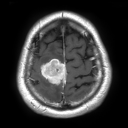

In [ ]:
from google.colab import files

# Upload the image file
uploaded = files.upload()

# Get the filename of the uploaded image
for fn in uploaded.keys():
  uploaded_img_path = fn

print(f"Uploaded file: {uploaded_img_path}")

# Load and preprocess the uploaded image
try:
    # Open, resize, and convert to RGB
    img = Image.open(uploaded_img_path).resize((IMG_WIDTH, IMG_HEIGHT)).convert('RGB')
    # Convert to numpy array and flatten
    img_array = np.array(img).flatten()

    # Scale the image features using the *same* scaler fitted on training data
    # The scaler expects a 2D array, so reshape img_array
    img_array_scaled = scaler.transform(img_array.reshape(1, -1))

    # Make prediction
    prediction_numeric = svm_model.predict(img_array_scaled)
    prediction_label = class_names[prediction_numeric[0]]

    print(f"\nPrediction for the uploaded image: {prediction_label}")

    # Display the uploaded image
    from IPython.display import display
    display(img)

except Exception as e:
    print(f"Error processing uploaded image: {e}")
    print("Please ensure you uploaded a valid image file.")
